<a href="https://colab.research.google.com/github/JennyCuba/Datasets/blob/main/DS3_JennyCuba_EntregaFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S&P 500 con titulares de noticias financieras (2008-2024)

## Introducción

En los mercados financieros, la información disponible en tiempo real puede influir significativamente en las decisiones de inversión y en la volatilidad de los activos. En particular, los titulares de noticias económicas y financieras pueden anticipar o reflejar movimientos relevantes en índices bursátiles como el S&P 500. En este contexto, el presente trabajo explora la relación entre el contenido textual de titulares financieros y el comportamiento del precio de cierre diario del índice S&P 500.

Para ello, se utiliza un conjunto de datos compuesto por más de 19.000 registros que abarcan el período comprendido entre 2008 y 2024. Cada fila del dataset contiene la fecha de negociación, el titular correspondiente y el precio de cierre del índice en esa jornada. A partir de este corpus, se aplican técnicas de procesamiento de lenguaje natural (NLP) y modelos de aprendizaje automático, incluyendo redes neuronales recurrentes como LSTM, para predecir el valor de cierre del índice basándose en la información textual y otras variables complementarias.

Este enfoque no solo permite evaluar el poder predictivo del lenguaje financiero sobre el comportamiento del mercado, sino también analizar cómo las emociones y el tono general de los titulares impactan en la dinámica bursátil. El objetivo final es construir un modelo que contribuya a mejorar la toma de decisiones basada en datos textuales y financieros, reduciendo la exposición a riesgos en contextos de alta incertidumbre.

## Librerias y herramientas

In [ ]:
!pip install tensorflow

In [ ]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 589.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.0 MB/s eta 0:00:00


In [ ]:
# Visualización y widgets
from IPython.display import display
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from wordcloud import WordCloud

# Manejo de datos
import pandas as pd
import numpy as np
from collections import Counter
import string

# NLP y preprocesamiento
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Modelado y evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack
import tensorflow as tf
from sentence_transformers import SentenceTransformer
import random
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Cargar el archivo CSV
file_path = "/content/drive/MyDrive/Colab Notebooks/sp500_headlines_2008_2024.csv"
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Title,Date,CP
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,1447.16
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,1447.16
2,2008 predictions for the S&P 500,2008-01-02,1447.16
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,1447.16
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,1416.18


In [ ]:
def explorar_dataframe(df, nombre):
    print("="*60)
    print(f"📊 Explorando el DataFrame: {nombre}")
    print("="*60)

    # Información general
    print("\n🧾 Información General:")
    df.info(verbose=False)  # No uses display aquí

    # Valores nulos
    print("\n🔍 Valores Nulos:")
    display(df.isnull().sum().to_frame(name='Cantidad de nulos'))

    # Valores únicos por columna
    print("\n🔢 Valores Únicos por Columna:")
    for columna in df.columns:
        print(f" - {columna}: {df[columna].nunique()} únicos")

    # Preview de las primeras filas
    print("\n👀 Primeras 5 filas:")
    display(df.head())

    print("\n")  # Espacio entre dataframes

# Ejecutar la función directamente
explorar_dataframe(df, "S&P 500")

📊 Explorando el DataFrame: S&P 500

🧾 Información General:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19127 entries, 0 to 19126
Columns: 3 entries, Title to CP
dtypes: float64(1), object(2)
memory usage: 448.4+ KB

🔍 Valores Nulos:


,Cantidad de nulos
Title,0
Date,0
CP,0



🔢 Valores Únicos por Columna:
 - Title: 18054 únicos
 - Date: 3507 únicos
 - CP: 3491 únicos

👀 Primeras 5 filas:


,Title,Date,CP
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,1447.16
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,1447.16
2,2008 predictions for the S&P 500,2008-01-02,1447.16
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,1447.16
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,1416.18


## EDA
Análisis de tendencia para los valores CP, en esta sección observo el comportamiendo del valor de cierre para el indice en el periodo 2008-2024, luego calculando el valor promedio de CP para cada mes de eso periodo podemos observar en un grafico de barras aquellos periodos mensuales que presentaron cambios abruptos, tambien agrego una herramienta de busqueda de titulares por fecha.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
# Agrupar por mes y calcular el valor promedio de cierre
cp_mensual = df.groupby(df['Date'].dt.to_period('M'))['CP'].mean().reset_index()
cp_mensual['Date'] = cp_mensual['Date'].astype(str)

# Crear gráfico interactivo
fig = px.line(
    cp_mensual,
    x='Date',
    y='CP',
    markers=True,
    title='📈 Tendencia Mensual del Valor de Cierre del S&P 500',
    labels={'Date': 'Mes', 'CP': 'Valor de Cierre Promedio'}
)

# Personalizar diseño
fig.update_traces(line=dict(width=2), marker=dict(size=8))
fig.update_layout(
    xaxis=dict(tickangle=45, tickfont=dict(size=12)),
    yaxis=dict(tickfont=dict(size=12)),
    template='plotly_dark',
    hovermode='x'
)

# Mostrar gráfico
fig.show()

In [ ]:
# Agrupar por mes y calcular el cierre promedio
cp_mensual = df.groupby(df['Date'].dt.to_period('M'))['CP'].mean().reset_index()
cp_mensual['Date'] = cp_mensual['Date'].astype(str)

# Calcular el cambio porcentual mensual
cp_mensual['pct_change'] = cp_mensual['CP'].pct_change() * 100

# Detectar cambios abruptos: más allá de ±2 desviaciones estándar
media = cp_mensual['pct_change'].mean()
std = cp_mensual['pct_change'].std()
cp_mensual['cambio_abrupto'] = cp_mensual['pct_change'].apply(
    lambda x: 'Abrupto' if abs(x - media) > 2 * std else 'Normal'
)

# Crear gráfico de barras con colores diferenciados
fig = px.bar(
    cp_mensual,
    x='Date',
    y='pct_change',
    color='cambio_abrupto',
    color_discrete_map={'Abrupto': 'red', 'Normal': 'green'},
    title='🔺 Variación Porcentual Mensual del S&P 500 con Cambios Abruptos',
    labels={'pct_change': 'Variación % mensual', 'Date': 'Mes'}
)

fig.update_layout(
    xaxis=dict(tickangle=45, tickfont=dict(size=11)),
    yaxis=dict(tickfont=dict(size=12)),
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

In [ ]:
# Crear widgets
anio_input = widgets.BoundedIntText(
    value=2008, min=2008, max=2024, step=1, description='Año:'
)

mes_input = widgets.BoundedIntText(
    value=1, min=1, max=12, step=1, description='Mes:'
)

dia_input = widgets.BoundedIntText(
    value=1, min=1, max=31, step=1, description='Día:'
)

output = widgets.Output()

# Función para mostrar titulares en la fecha específica
def mostrar_titulares_dia(anio, mes, dia):
    try:
        fecha_obj = pd.to_datetime(f"{anio}-{mes:02d}-{dia:02d}")
    except:
        return pd.DataFrame([["Fecha inválida", "", ""]], columns=["Date", "Title", "CP"])

    return df[df['Date'] == fecha_obj][['Date', 'Title', 'CP']].sort_values(by='Date').head(10)

# Acción al hacer clic en el botón
def on_button_click(b):
    output.clear_output()
    with output:
        resultados = mostrar_titulares_dia(anio_input.value, mes_input.value, dia_input.value)
        display(resultados)

# Botón de búsqueda
boton = widgets.Button(description="🔍 Mostrar Titulares")
boton.on_click(on_button_click)

# Mostrar todo junto
display(widgets.HBox([anio_input, mes_input, dia_input, boton]), output)

Output()

## Procesamiento NLP

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from font(s) DejaVu Sans.



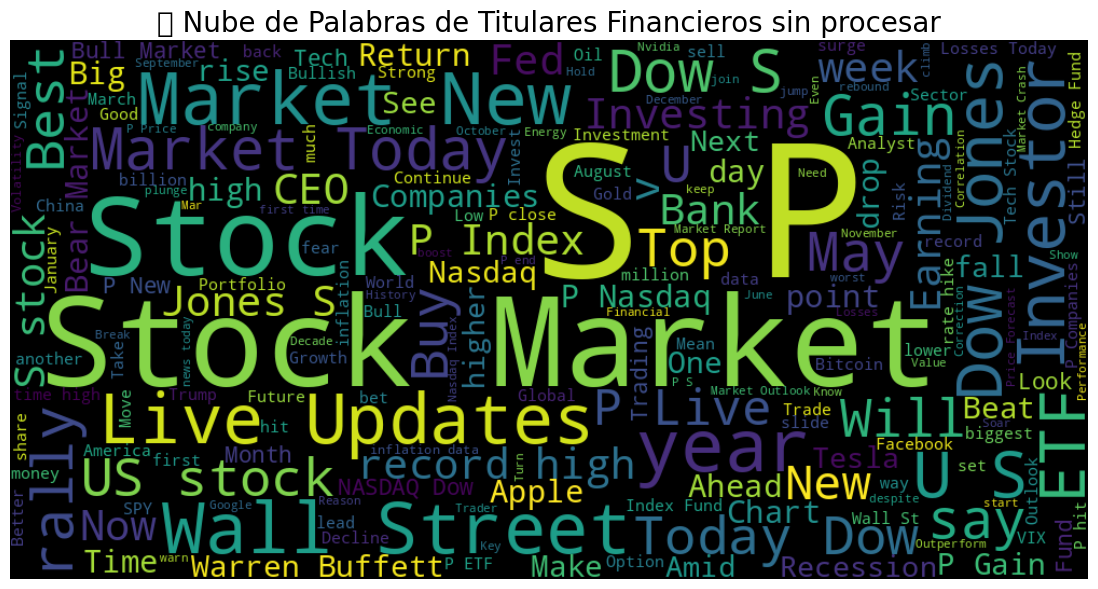

In [ ]:
# Unir todos los titulares
texto = " ".join(df['Title'].dropna().astype(str))

# Crear la nube de palabras
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black',
    max_words=200,
    colormap='viridis'
).generate(texto)

# Mostrar la nube de palabras
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("📢 Nube de Palabras de Titulares Financieros sin procesar", fontsize=20)
plt.show()

Limpieza de datos

In [ ]:
# Seleccionamos las columnas relevantes para el análisis de lenguaje natural (NLP)
df_titulares = df[['Title']].drop_duplicates(subset='Title')

# Mostramos las primeras filas del dataframe seleccionado para revisar los datos
df_titulares.head()

,Title
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net"""
1,Dow Tallies Biggest First-session-of-year Poin...
2,2008 predictions for the S&P 500
3,"U.S. Stocks Higher After Economic Data, Monsan..."
4,U.S. Stocks Climb As Hopes Increase For More F...


Función para limpiar y tokenizar

In [ ]:
nltk.download('stopwords', quiet=True)
STOPWORDS = set(stopwords.words('english'))

# Función para limpiar y tokenizar
def limpiar_y_tokenizar(texto):
    if not isinstance(texto, str):
        return "", []

    # Minúsculas y sin puntuación
    texto_limpio = texto.lower().translate(str.maketrans('', '', string.punctuation))
    palabras = texto_limpio.split()

    # Remover stopwords
    palabras_filtradas = [palabra for palabra in palabras if palabra not in STOPWORDS]

    return " ".join(palabras_filtradas), palabras_filtradas

# Función principal para aplicar al dataframe
def preprocesar_titulares(df):
    df[['titulo_limpio', 'tokens_titulo']] = df['Title'].apply(
        lambda texto: pd.Series(limpiar_y_tokenizar(texto))
    )
    return df

# Aplicar al dataset
df_titulares = preprocesar_titulares(df)

# Ver primeras filas
df_titulares[['Title', 'titulo_limpio', 'tokens_titulo']].head()

,Title,titulo_limpio,tokens_titulo
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",jpmorgan predicts 2008 nothing net,"[jpmorgan, predicts, 2008, nothing, net]"
1,Dow Tallies Biggest First-session-of-year Poin...,dow tallies biggest firstsessionofyear point d...,"[dow, tallies, biggest, firstsessionofyear, po..."
2,2008 predictions for the S&P 500,2008 predictions sp 500,"[2008, predictions, sp, 500]"
3,"U.S. Stocks Higher After Economic Data, Monsan...",us stocks higher economic data monsanto outlook,"[us, stocks, higher, economic, data, monsanto,..."
4,U.S. Stocks Climb As Hopes Increase For More F...,us stocks climb hopes increase fed moves,"[us, stocks, climb, hopes, increase, fed, moves]"


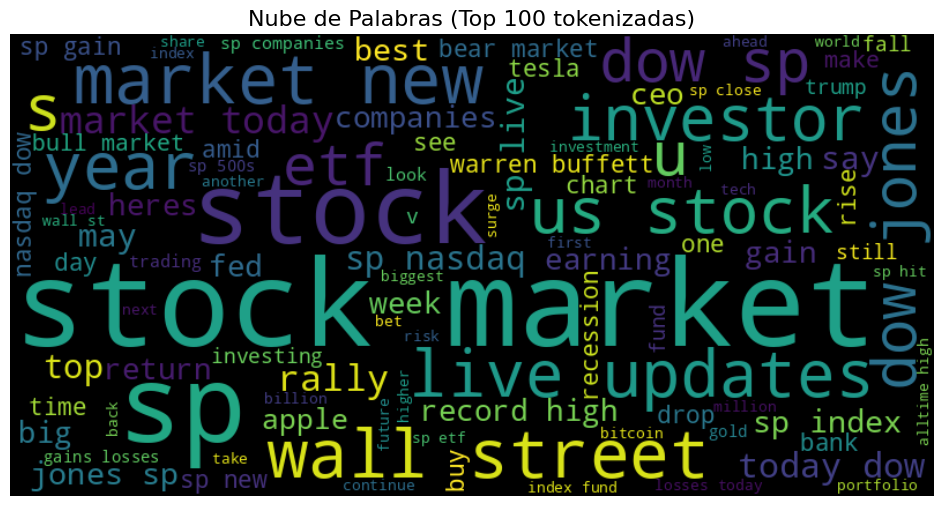

In [ ]:
# Unir todos los tokens en un solo texto
texto_unido = " ".join([palabra for sublista in df_titulares['tokens_titulo'] for palabra in sublista])

# Crear el objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='black', max_words=100).generate(texto_unido)

# Mostrar la nube
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras (Top 100 tokenizadas)', fontsize=16)
plt.show()


Preclasificacion de sentimientos

In [ ]:
# Descargar recursos necesarios
nltk.download('vader_lexicon')

# Inicializar analizador
analizador = SentimentIntensityAnalyzer()

# Función para clasificar sentimiento
def clasificar_sentimiento(texto):
    if not isinstance(texto, str):
        return 0, "Neutro"

    puntaje = analizador.polarity_scores(texto)['compound']

    if puntaje > 0:
        return puntaje, "Positivo 😊"
    elif puntaje < 0:
        return puntaje, "Negativo 😡"
    else:
        return puntaje, "Neutro 😐"

# Aplicar al DataFrame de titulares
df_titulares[['sentiment_score', 'sentiment_label']] = df_titulares['Title'].apply(
    lambda t: pd.Series(clasificar_sentimiento(t))
)

# Mostrar ejemplo
df_titulares[['Title', 'sentiment_score', 'sentiment_label']].head()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,Title,sentiment_score,sentiment_label
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",0.0000,Neutro 😐
1,Dow Tallies Biggest First-session-of-year Poin...,-0.2732,Negativo 😡
2,2008 predictions for the S&P 500,0.0000,Neutro 😐
3,"U.S. Stocks Higher After Economic Data, Monsan...",0.0000,Neutro 😐
4,U.S. Stocks Climb As Hopes Increase For More F...,0.6249,Positivo 😊


Frecuencia de palabras más comunes en los titulares

In [ ]:
# 🔢 Función para obtener los tokens o n-gramas más frecuentes
def obtener_top_tokens(df, columna_tokens='tokens_titulo', top_n=50):
    todos_los_tokens = [token for tokens in df_titulares[columna_tokens] for token in tokens]
    conteo_tokens = Counter(todos_los_tokens)
    return conteo_tokens.most_common(top_n)

# 📄 Función para crear un DataFrame desde los conteos de frecuencia
def crear_df_frecuencias(conteo, columnas=['Palabra', 'Frecuencia']):
    return pd.DataFrame(conteo.items(), columns=columnas)

# 📊 Función general para crear gráficos de barras interactivos
def graficar_frecuencias_top(df, titulo, xlabel, nombre_columna):
    fig = px.bar(
        df,
        x=nombre_columna,
        y='Frecuencia',
        title=titulo,
        labels={nombre_columna: xlabel, 'Frecuencia': 'Frecuencia'},
        color='Frecuencia',
        color_continuous_scale='Viridis'
    )

    fig.update_layout(
        template='plotly_dark',
        xaxis_title=xlabel,
        yaxis_title='Frecuencia',
        title={'x': 0.5, 'y': 0.95, 'font': {'size': 20, 'family': 'Arial, sans-serif'}},
        xaxis=dict(tickangle=45),
        yaxis=dict(showgrid=True, gridcolor='gray'),
        bargap=0.2
    )
    fig.show()

# 🔍 Aplicar: obtener los top 50 tokens y graficar los 25 más comunes
top_50_tokens = obtener_top_tokens(df, 'tokens_titulo', top_n=50)
df_top_50_tokens = crear_df_frecuencias(dict(top_50_tokens))

graficar_frecuencias_top(
    df_top_50_tokens.head(20),
    '📈 Top 25 Palabras Más Frecuentes en Titulares Financieros',
    'Palabra',
    'Palabra'
)

Análisis de bigramas



In [ ]:
# 🔠 Unir los textos limpios para crear bigramas
titulos_limpios = df_titulares['titulo_limpio'].dropna()

# Vectorizador para bigramas
vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=1000)
X = vectorizer.fit_transform(titulos_limpios)

# Sumar ocurrencias de cada bigrama
bigramas = vectorizer.get_feature_names_out()
frecuencias = X.sum(axis=0).A1

# Crear DataFrame con resultados
df_bigramas = pd.DataFrame({'Bigrama': bigramas, 'Frecuencia': frecuencias})
df_bigramas = df_bigramas.sort_values(by='Frecuencia', ascending=False).head(15)

# 📊 Gráfico de barras interactivo con fondo oscuro
fig = px.bar(
    df_bigramas,
    x='Bigrama',
    y='Frecuencia',
    title='📊 Top 15 Bigramas Más Frecuentes en Titulares',
    labels={'Bigrama': 'Bigrama', 'Frecuencia': 'Frecuencia'},
    color='Frecuencia',
    color_continuous_scale='Cividis'
)

fig.update_layout(
    template='plotly_dark',
    xaxis_title='Bigrama',
    yaxis_title='Frecuencia',
    title={'x': 0.5, 'y': 0.95},
    xaxis=dict(tickangle=45),
    bargap=0.2
)

fig.show()

Distribucion de sentimientos

In [ ]:
# Contar la cantidad de cada categoría de sentimiento
sentiment_counts = df_titulares["sentiment_label"].value_counts().reset_index()
sentiment_counts.columns = ["Sentimiento", "Cantidad"]

# Crear gráfico de torta interactivo con colores Viridis
fig = px.pie(
    sentiment_counts,
    values="Cantidad",
    names="Sentimiento",
    title="📊 Distribución de Sentimientos en Titulares Financieros",
    color_discrete_sequence=px.colors.sequential.Viridis
)

# Personalizar diseño con fondo negro
fig.update_layout(
    template="plotly_dark",
    title_font_size=16,
    title_x=0.5  # Centrar título
)

# Mostrar gráfico
fig.show()

A partir del análisis de sentimientos podriamos evaluar dos escenarios posibles, uno basado en el análisis de sentimientos de los titulares para decidir invertir o no en el mercado y otro en el que no se utilice el análisis de sentiminetos. El objetivo es ver de que manera el análisis de sentimientos me puede servir como herramienta en el mercado de inversiones.

## Estrategia 1: Basada en el análisis de sentimientos

✅ Supuestos para la simulación:
Se parte con una inversión inicial de 10.000 USD.

Estrategia de inversión:

Sentimiento positivo: comprar (se asume una rentabilidad si el índice sube al día siguiente).

Sentimiento negativo: vender (o quedarse fuera del mercado).

Sentimiento neutro: mantener.

Se calcula la rentabilidad diaria hipotética usando el valor de cierre del día siguiente.

Se asume que cada día se actúa según el sentimiento promedio de los titulares de ese día.



In [ ]:
# Estrategia con análisis de sentimientos
# Paso 1: sentimiento promedio diario
sent_diario = df_titulares.groupby('Date')['sentiment_score'].mean().reset_index()
sent_diario.columns = ['Date', 'sentiment_mean']

# Paso 2: añadir valor de cierre diario (CP)
sent_diario = pd.merge(sent_diario, df[['Date', 'CP']].drop_duplicates(), on='Date')

# Paso 3: calcular retorno diario del índice
sent_diario = sent_diario.sort_values('Date')
sent_diario['CP_next'] = sent_diario['CP'].shift(-1)
sent_diario['daily_return'] = (sent_diario['CP_next'] - sent_diario['CP']) / sent_diario['CP']

# Paso 4: simular inversión
capital = 10000
capital_history = [capital]

for i, row in sent_diario.iterrows():
    sentimiento = row['sentiment_mean']
    retorno = row['daily_return']

    if pd.isna(retorno):
        capital_history.append(capital)
        continue

    if sentimiento > 0:  # Comprar (asume retorno del mercado)
        capital *= (1 + retorno)
    elif sentimiento < 0:  # Vender (no invierte ese día)
        capital = capital
    else:  # Neutro
        capital = capital

    capital_history.append(capital)

# Paso 5: generar resultados
sent_diario['capital'] = capital_history[:-1]  # última no se usa

## Estrategia 2: Sin análisis de sentimientos (Pasiva)

Vamos a comparar la estrategia de inversión basada en sentimientos con una estrategia pasiva, donde el inversor simplemente:

Compra en 2008 con $10.000

Mantiene su inversión en el índice S&P 500 todo el tiempo

El capital se ajusta todos los días según la variación del índice

In [ ]:
# Estrategia pasiva: comprar y mantener
capital_pasivo = 10000
capital_hist_pasiva = [capital_pasivo]

for retorno in sent_diario['daily_return']:
    if pd.isna(retorno):
        capital_hist_pasiva.append(capital_pasivo)
        continue
    capital_pasivo *= (1 + retorno)
    capital_hist_pasiva.append(capital_pasivo)

# Añadir al DataFrame para comparar
sent_diario['capital_pasiva'] = capital_hist_pasiva[:-1]  # última fila no se usa

In [ ]:
fig = go.Figure()

# Línea 1: Estrategia basada en sentimientos
fig.add_trace(go.Scatter(
    x=sent_diario['Date'],
    y=sent_diario['capital'],
    mode='lines',
    name='💡 Estrategia por Sentimiento',
    line=dict(color='dodgerblue')
))

# Línea 2: Estrategia pasiva
fig.add_trace(go.Scatter(
    x=sent_diario['Date'],
    y=sent_diario['capital_pasiva'],
    mode='lines',
    name='📉 Estrategia Pasiva (Buy & Hold)',
    line=dict(color='red', dash='dash')
))

# Línea 3: Valor real del índice S&P 500 (escalado para que sea comparable)
# Escalamos CP a rango similar al capital para que sea visible
cp_escala = sent_diario['CP'] * (10000 / sent_diario['CP'].iloc[0])

fig.add_trace(go.Scatter(
    x=sent_diario['Date'],
    y=cp_escala,
    mode='lines',
    name='💹 Valor de Cierre S&P 500 (Escalado)',
    line=dict(color='yellow', width=2, dash='dot')
))

# Diseño del gráfico
fig.update_layout(
    title='📊 Comparación de Estrategias vs Valor Real del S&P 500',
    xaxis_title='Fecha',
    yaxis_title='Capital Acumulado ($)',
    template='plotly_dark',
    legend=dict(x=0.01, y=0.99),
    hovermode='x unified'
)

fig.show()

| Criterio                   | Estrategia por Sentimiento | Estrategia Pasiva |
| -------------------------- | -------------------------- | ----------------- |
| Rendimiento final          | \~26.000 USD               | \~35.000 USD      |
| Volatilidad (riesgo)       | Menor                      | Mayor             |
| Simplicidad de ejecución   | Alta                       | Muy alta          |
| Dependencia del modelo NLP | Sí                         | No                |


➡️ Si buscás seguridad y menos exposición, la estrategia por sentimiento es más defensiva.

➡️ Si querés rendimiento máximo a largo plazo, la estrategia pasiva suele ganar… pero tenés que tolerar más caídas.

Observaciones: como podemos ver la estrategia pasiva da un mayor rendimineto, ya que se comporta igual al valor de cierre del S&P500, asi se aprovecha al máximo cada alza en el mercado, sin embargo hay que tener en cuenta que las caídas también pueden ser abruptas dependiendo de muchas variables del mercado global y diferentes acontesimientos a nivel mundial, es decir el modelo de inversión es muy volátil, a eso podemos sumarle que es rentable en periodos muy largos. Por otro lado podemos notar que la estrategia por sentimiento de los titulares es mucho mas conservadora y evita muchos días de mercado negativo (a notarse crisis del periodo 2008-2011 y la caída abrupta del 2020 por pandemia). Por lo tanto podriamos considerar el análisis de sentimientos de los titulares como una herramienta estrategica para reducir las pérdidas en el mercado de inversiones y optimizar las ganancias en plazos mas cortos. partiendo de esta idea podemos complementar NLP y el desarrollo de una red neuronal que me sugiera en función de determinadas variables si es momento de invertir o no.

## Vectorizacion y modelado

In [ ]:
df_titulares['lemmatized'] = df_titulares['titulo_limpio']  # o df['clean_title']

In [ ]:
df_titulares

,Title,Date,CP,titulo_limpio,tokens_titulo,sentiment_score,sentiment_label,lemmatized
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,1447.16,jpmorgan predicts 2008 nothing net,"[jpmorgan, predicts, 2008, nothing, net]",0.0000,Neutro 😐,jpmorgan predicts 2008 nothing net
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,1447.16,dow tallies biggest firstsessionofyear point d...,"[dow, tallies, biggest, firstsessionofyear, po...",-0.2732,Negativo 😡,dow tallies biggest firstsessionofyear point d...
2,2008 predictions for the S&P 500,2008-01-02,1447.16,2008 predictions sp 500,"[2008, predictions, sp, 500]",0.0000,Neutro 😐,2008 predictions sp 500
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,1447.16,us stocks higher economic data monsanto outlook,"[us, stocks, higher, economic, data, monsanto,...",0.0000,Neutro 😐,us stocks higher economic data monsanto outlook
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,1416.18,us stocks climb hopes increase fed moves,"[us, stocks, climb, hopes, increase, fed, moves]",0.6249,Positivo 😊,us stocks climb hopes increase fed moves
...,...,...,...,...,...,...,...,...
19122,REITs vs. Stocks: What Does the Data Say?,2024-03-04,5130.95,reits vs stocks data say,"[reits, vs, stocks, data, say]",0.0000,Neutro 😐,reits vs stocks data say
19123,"Nasdaq Index, Dow Jones, S&P 500 News: Futures...",2024-03-04,5130.95,nasdaq index dow jones sp 500 news futures mix...,"[nasdaq, index, dow, jones, sp, 500, news, fut...",0.0000,Neutro 😐,nasdaq index dow jones sp 500 news futures mix...
19124,"Nasdaq 100, Dow Jones, S&P 500 News: Cautious ...",2024-03-04,5130.95,nasdaq 100 dow jones sp 500 news cautious trad...,"[nasdaq, 100, dow, jones, sp, 500, news, cauti...",-0.1027,Negativo 😡,nasdaq 100 dow jones sp 500 news cautious trad...
19125,"Bank of America boosts S&P 500 target to 5,400...",2024-03-04,5130.95,bank america boosts sp 500 target 5400 here’s got,"[bank, america, boosts, sp, 500, target, 5400,...",0.3182,Positivo 😊,bank america boosts sp 500 target 5400 here’s got


## Modelo 1 Variables: Texto, sentimiento, estacionalidad

Para este modelo definimos df final y agregamos dos variables estacionales generadas a partir del valor CP: "CP_quarter_avg" que es el valor promedio CP del último trimestre y "CP_same_period_last_year" que es el valor promedio CP del mismo trimestre pero del año anterior, el objetivo es darle al modelo variables estacionales representativas en el mercado de valores, ya que un modelo basado solo en los titulares sería muy poco preciso.

In [ ]:
df_modelos = df_titulares.copy()

In [ ]:
# Ordenar por fecha por si acaso
df_modelos = df_modelos.sort_values('Date')

# Calcular promedio de los últimos 90 días (CP_quarter_avg)
df_modelos['CP_quarter_avg'] = df_modelos['CP'].shift(1).rolling(window=90).mean()

# Crear diccionario con CP por fecha para buscar el valor del año anterior
cp_dict = df_modelos.set_index('Date')['CP'].to_dict()

# Calcular la fecha del mismo periodo el año anterior
df_modelos['year_ago'] = df_modelos['Date'] - pd.DateOffset(years=1)

# Buscar promedio alrededor de esa fecha del año pasado
def buscar_promedio_anual(d):
    fechas_vecinas = pd.date_range(d - pd.Timedelta(days=7), d + pd.Timedelta(days=7))
    valores = [cp_dict.get(fecha) for fecha in fechas_vecinas if cp_dict.get(fecha) is not None]
    return np.mean(valores) if valores else np.nan

df_modelos['CP_same_period_last_year'] = df_modelos['year_ago'].apply(buscar_promedio_anual)

# Eliminar filas con nulos para evitar errores en el entrenamiento
df_modelos = df_modelos.dropna(subset=['CP_quarter_avg', 'CP_same_period_last_year'])

In [ ]:
# Vectorizar titulares
vectorizer = TfidfVectorizer(max_features=5000)
X_text = vectorizer.fit_transform(df_modelos['lemmatized'])

# Usar solo sentimiento, promedio 3 meses y año anterior
X_extra = df_modelos[['sentiment_score', 'CP_quarter_avg', 'CP_same_period_last_year']].values
X_final = hstack([X_text, X_extra])

# Variable objetivo
y = df_modelos['CP'].values

# División
X_train, X_test, y_train, y_test = train_test_split(X_final.toarray(), y, test_size=0.2, random_state=42)

# Red neuronal
modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])
modelo.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

# Predicciones
y_pred = modelo.predict(X_test).flatten()

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📊 MAE: {mae:.2f}")
print(f"📊 RMSE: {rmse:.2f}")
print(f"📊 R²: {r2:.4f}")

119/119 [==============================] - 0s 3ms/step
📊 MAE: 47.00
📊 RMSE: 67.29
📊 R²: 0.9964


In [ ]:
# Crear DataFrame para el gráfico
df_resultados = pd.DataFrame({
    'Real': y_test,
    'Predicho': y_pred
})

# Gráfico de dispersión interactivo
fig = px.scatter(
    df_resultados,
    x='Real',
    y='Predicho',
    title='📊 Predicciones vs Valores Reales del S&P 500 (Modelo con Estacionalidad)',
    labels={'Real': 'Valor Real de Cierre', 'Predicho': 'Valor Predicho'},
    opacity=0.6,
    color_discrete_sequence=['lightgreen'],
    width=800,
    height=500
)

# Línea de referencia (y = x)
fig.add_shape(
    type='line',
    x0=df_resultados['Real'].min(),
    y0=df_resultados['Real'].min(),
    x1=df_resultados['Real'].max(),
    y1=df_resultados['Real'].max(),
    line=dict(color='red', dash='dash'),
    name='Referencia'
)

fig.update_layout(template='plotly_dark')
fig.show()

Como se puede observar en el gráfico de linea y por las métricas obtenidas el modelo explica el 99.6% de la variabilidad del índice. Pero para ver que tanta influencia tiene el análisis de sentimiento en este modelo, en el modelo 2 evaluamos solo las variables estacionales, así podemos hacer una comparación.

## Modelo 2 Variables: Solo numéricas estacionales

In [ ]:
# Variables independientes y target
X_numerico = df_modelos[['CP_quarter_avg', 'CP_same_period_last_year']].values
y = df_modelos['CP'].values

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X_numerico, y, test_size=0.2, random_state=42)

# Modelo de red neuronal simple
modelo_numerico = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])
modelo_numerico.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenamiento
modelo_numerico.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

# Evaluación
y_pred = modelo_numerico.predict(X_test).flatten()
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Mostrar resultados
print(f"📊 MAE: {mae:.2f}")
print(f"📊 RMSE: {rmse:.2f}")
print(f"📊 R²: {r2:.4f}")

119/119 [==============================] - 0s 1ms/step
📊 MAE: 52.60
📊 RMSE: 69.30
📊 R²: 0.9962


Podemos ver que el modelo solo con variables númericas de CP es aun mejor que el modelo que incluye análisis de sentimientos, esto quiere decir que las variables estacionales por si solas son muy poderosas y el análisis de titulares aporta valor marginal, útil en escenarios con eventos inesperados, pero no tan dominante si tenés buen contexto histórico.

# Modelo 3 Variables: sentimiento y numéricas estacionales

El modelo 3 tiene como objetivo poder hacer una comparación de los valores CP reales y predichos en todo el periodo evaluado 2008-2024 (ya que los modelos evaluados anteriormente tienen una red neuronal alimentada directamente con una fila (día) a la vez y no consideran la secuencia temporal de eventos pasados). Por eso el modelo 3 utiliza LSTM (Long Short-Term Memory): un tipo de red recurrente que entiende dependencias temporales y embeddings que capturan semántica de los textos, así este modelo puede aprender patrones históricos y puedo visualizar el comportamiento en el tiempo de los valores predichos.



In [ ]:
df_m3 = df_modelos.copy()

In [ ]:
# Cargar modelo preentrenado (rápido y eficiente)
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Calcular embedding promedio por titular
embeddings = embedder.encode(df_m3['lemmatized'].astype(str).tolist(), show_progress_bar=True)

# Convertir a DataFrame y unir con features numéricos
df_embed = pd.DataFrame(embeddings)
df_embed.columns = [f"embed_{i}" for i in range(df_embed.shape[1])]

# Aseguramos que ambos DataFrames tengan índices alineados
df_final = pd.concat([df_m3.reset_index(drop=True), df_embed], axis=1)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/594 [00:00<?, ?it/s]

In [ ]:
# Features: embeddings + sentiment + variables estacionales
feature_cols = [col for col in df_final.columns if col.startswith('embed_')] + [
    'sentiment_score', 'CP_quarter_avg', 'CP_same_period_last_year'
]
target_col = 'CP'

# Normalizar features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_final[feature_cols].fillna(0))
y = df_final[target_col].values

# Crear ventanas de secuencia
def create_sequences(X, y, window=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y, window=10)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

# Predicción
y_pred = model_lstm.predict(X_test).flatten()
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"📊 MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"📊 RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"📊 R²: {r2_score(y_test, y_pred):.4f}")

Epoch 1/10
427/427 [==============================] - 19s 29ms/step - loss: 11240298.0000 - mae: 3153.1343 - val_loss: 9669649.0000 - val_mae: 2896.1179
Epoch 2/10
427/427 [==============================] - 10s 24ms/step - loss: 7758509.0000 - mae: 2532.4375 - val_loss: 5469383.5000 - val_mae: 2050.5896
Epoch 3/10
427/427 [==============================] - 9s 20ms/step - loss: 3859215.0000 - mae: 1669.2933 - val_loss: 2405320.5000 - val_mae: 1304.5706
Epoch 4/10
427/427 [==============================] - 7s 16ms/step - loss: 1818531.3750 - mae: 1165.2974 - val_loss: 1400382.8750 - val_mae: 1039.9773
Epoch 5/10
427/427 [==============================] - 6s 13ms/step - loss: 1354013.8750 - mae: 1034.6636 - val_loss: 1329070.3750 - val_mae: 1015.9485
Epoch 6/10
427/427 [==============================] - 6s 14ms/step - loss: 1207303.3750 - mae: 977.6371 - val_loss: 957278.8125 - val_mae: 876.1693
Epoch 7/10
427/427 [==============================] - 6s 13ms/step - loss: 537113.0000 - mae: 

## Mejoras al modelo LSTM

Aplico las siguientes mejoras, integrando:

Análisis de sentimiento granular (pos, neu, neg), con esto el modelo mide que tan positivo o negativo es un titular, ayuda a entender mejor el matiz emocional.

Dropout para evitar overfitting, apaga algunas neuronas durante el entrenamiento, evita que el modelo memorice el entrenamiento.

Pérdida Huber para sensibilidad a errores grandes, estabiliza las predicciones.

EarlyStopping para parar a tiempo, patience=5: si después de 5 épocas el modelo no mejora en val_loss, se detiene. Esto ahorra tiempo de entrenamiento y evita sobreentrenar.



In [ ]:
df_m3 = df_modelos.copy()

In [ ]:
# ---------- MEJORA 1: Análisis de sentimiento granular ----------
analizador = SentimentIntensityAnalyzer()

def extraer_scores_vader(texto):
    if not isinstance(texto, str):
        return 0, 0, 0
    scores = analizador.polarity_scores(texto)
    return scores['pos'], scores['neu'], scores['neg']

df_m3[['pos_score', 'neu_score', 'neg_score']] = df_m3['Title'].apply(lambda t: pd.Series(extraer_scores_vader(t)))

# ---------- Embeddings del texto ----------
embedder = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedder.encode(df_m3['lemmatized'].astype(str).tolist(), show_progress_bar=True)
df_embed = pd.DataFrame(embeddings)
df_embed.columns = [f"embed_{i}" for i in range(df_embed.shape[1])]
df_embed.reset_index(drop=True, inplace=True)

# ---------- Concatenar embeddings y variables ----------
df_final = pd.concat([df_m3.reset_index(drop=True), df_embed], axis=1)

# ---------- Features seleccionadas ----------
feature_cols = [col for col in df_embed.columns] + [
    'sentiment_score', 'pos_score', 'neg_score',
    'CP_quarter_avg', 'CP_same_period_last_year'
]
target_col = 'CP'

# ---------- Escalado ----------
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_final[feature_cols].fillna(0))
y = df_final[target_col].values

# ---------- Crear ventanas para LSTM ----------
def create_sequences(X, y, window=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - window):
        X_seq.append(X[i:i+window])
        y_seq.append(y[i+window])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y, window=10)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# ---------- Modelo LSTM con mejoras ----------
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    tf.keras.layers.Dropout(0.3),  # Regularización
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model_lstm.compile(
    optimizer='adam',
    loss=Huber(delta=100.0),  # Función de pérdida sensible
    metrics=['mae']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ---------- Entrenamiento ----------
history = model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# ---------- Predicción y métricas ----------
y_pred = model_lstm.predict(X_test).flatten()

print(f"📊 MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"📊 RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"📊 R²: {r2_score(y_test, y_pred):.4f}")

Batches:   0%|          | 0/594 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/100
427/427 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 316470.0312 - mae: 3214.7007 - val_loss: 270061.4688 - val_mae: 2750.6143
Epoch 2/100
427/427 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 244776.3125 - mae: 2497.6497 - val_loss: 146750.5000 - val_mae: 1516.7546
Epoch 3/100
427/427 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 131903.1094 - mae: 1368.2916 - val_loss: 99524.6250 - val_mae: 1043.9852
Epoch 4/100
427/427 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 100231.5000 - mae: 1051.5332 - val_loss: 94877.4219 - val_mae: 998.2775
Epoch 5/100
427/427 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 95730.2266 - mae: 1006.6795 - val_loss: 84758.8047 - val_mae: 896.8745
Epoch 6/100
427/427 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 64568.9531 - mae: 694.2697 - val_loss: 22944.4922 - val_mae: 276.2771
Epoch 7/100
427/427 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 30524.6582 - mae: 352.3004 - val_loss: 17751.0039 - val_mae: 223.3106
Epoch 8/100
427/427 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss:

## Comparación de CP real vs predicho

In [ ]:
# Crear todas las secuencias posibles para predicción completa
X_seq_full, _ = create_sequences(X_scaled, y, window=10)

# Predecir CP con el modelo LSTM entrenado
y_pred_full = model_lstm.predict(X_seq_full).flatten()

# Crear un nuevo DataFrame con resultados
df_pred = df.iloc[len(df) - len(y_pred_full):].copy()
df_pred['CP_predicho_lstm'] = y_pred_full

594/594 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_pred['Date'], y=df_pred['CP'],
    mode='lines', name='CP Real',
    line=dict(color='royalblue', width=2)
))

fig.add_trace(go.Scatter(
    x=df_pred['Date'], y=df_pred['CP_predicho_lstm'],
    mode='lines', name='CP Predicho (LSTM)',
    line=dict(color='orange', dash='dash', width=2)
))

fig.update_layout(
    title='📈 Valor de Cierre del S&P 500: Real vs Predicho (LSTM)',
    xaxis_title='Fecha',
    yaxis_title='CP',
    template='plotly_dark',
    hovermode='x unified'
)

fig.show()

Observaciones del gráfico: Las predicciones del modelo se fueron ajustando en tramos de 10 días por eso podemos visualizar los valores predichos como una linea punteada, a simple vista las lineas de tendencia son similares pero si hacemos zoom en la imagen podemos ver que se suavizan algunas caidas. El modelo captura adecuadamente la tendencia general del mercado a lo largo del período 2008-2024, mostrando una alta correlación entre la serie real y la predicha. Con este análisis podemos ver que si bien la influencia del análisis de sentimientos como variable es marginal, puede representar una herramienta poderosa para evaluar el mercado y reducir las posibles pérdidas.

## Winget herramienta de inversión

In [ ]:
# Crear inputs
titulares_input = widgets.Textarea(
    value='Stocks rally as Fed signals rate pause',
    placeholder='Ingresá los titulares financieros del día',
    description='Titulares:',
    layout=widgets.Layout(width='100%', height='100px')
)

cp_quarter_avg_input = widgets.FloatText(
    description='Prom. CP últimos 3 meses:'
)

cp_same_period_last_year_input = widgets.FloatText(
    description='CP mismo periodo año anterior:'
)

boton_predecir = widgets.Button(
    description='📊 Predecir con LSTM',
    button_style='info'
)

output_prediccion = widgets.Output()

# Función de predicción con validaciones
def predecir_lstm(b):
    output_prediccion.clear_output()
    with output_prediccion:
        texto = titulares_input.value.strip()

        if not texto:
            print("⚠️ Por favor, ingresá un titular válido.")
            return

        try:
            # Generar embeddings y features
            embedding = embedder.encode([texto])[0]
            scores = analizador.polarity_scores(texto)
            sentiment = scores['compound']
            pos_score = scores['pos']
            neg_score = scores['neg']
            cp_avg = cp_quarter_avg_input.value
            cp_last_year = cp_same_period_last_year_input.value

            # Validar que los valores no estén vacíos o cero
            if cp_avg == 0.0 or cp_last_year == 0.0:
                print("⚠️ Ingresá valores reales para CP (trimestre y año anterior).")
                return

            # Vector de entrada
            feature_vector_unscaled = np.concatenate([
                embedding,
                [sentiment, pos_score, neg_score, cp_avg, cp_last_year]
            ]).reshape(1, -1)

            # Escalar y formar secuencia para LSTM
            feature_vector_scaled = scaler.transform(feature_vector_unscaled)
            secuencia_scaled = np.array([feature_vector_scaled[0]] * 10)
            entrada_lstm = np.expand_dims(secuencia_scaled, axis=0)  # (1, 10, 387)

            # Predicción
            prediccion = model_lstm.predict(entrada_lstm)[0][0]
            print(f"\n📈 Valor estimado del S&P 500: **{prediccion:.2f}**")

            # Recomendación
            if prediccion > cp_avg * 1.02:
                print("🟢 Sugerencia: COMPRAR — El valor predicho sugiere un posible aumento.")
            elif prediccion < cp_avg * 0.98:
                print("🔴 Sugerencia: VENDER — El valor predicho sugiere una posible caída.")
            else:
                print("⚪ Sugerencia: MANTENER — Valor dentro del rango esperado.")

        except Exception as e:
            print("❌ Error durante la predicción:")
            print(str(e))

# Conectar botón
boton_predecir.on_click(predecir_lstm)

# Mostrar widget completo
display(widgets.VBox([
    titulares_input,
    cp_quarter_avg_input,
    cp_same_period_last_year_input,
    boton_predecir,
    output_prediccion
]))

In [ ]:
# Escenarios a evaluar
escenarios = pd.DataFrame({
    'Titular': [
        "Stocks fall sharply as inflation fears grow",
        "Markets surge after strong earnings reports",
        "Federal Reserve maintains interest rates steady",
        "Tech stocks rise despite global slowdown concerns",
        "Markets react to geopolitical tensions in Asia"
    ],
    'CP_quarter_avg': [4200, 4400, 4500, 4300, 4100],
    'CP_same_period_last_year': [3900, 4100, 4450, 4000, 3950]
})

# Procesar todos los escenarios
def evaluar_escenarios(df_escenarios):
    resultados = []

    for i, row in df_escenarios.iterrows():
        try:
            texto = row['Titular']
            embedding = embedder.encode([texto])[0]
            scores = analizador.polarity_scores(texto)
            sentiment = scores['compound']
            pos_score = scores['pos']
            neg_score = scores['neg']
            cp_avg = row['CP_quarter_avg']
            cp_last_year = row['CP_same_period_last_year']

            # Vector de entrada
            feature_vector_unscaled = np.concatenate([
                embedding, [sentiment, pos_score, neg_score, cp_avg, cp_last_year]
            ]).reshape(1, -1)

            # Escalar
            feature_vector_scaled = scaler.transform(feature_vector_unscaled)

            # Crear secuencia para LSTM
            secuencia_scaled = np.array([feature_vector_scaled[0]] * 10)
            entrada_lstm = np.expand_dims(secuencia_scaled, axis=0)

            # Predecir
            pred = model_lstm.predict(entrada_lstm)[0][0]

            # Recomendación
            if pred > cp_avg * 1.02:
                decision = "🟢 COMPRAR"
            elif pred < cp_avg * 0.98:
                decision = "🔴 VENDER"
            else:
                decision = "⚪ MANTENER"

            resultados.append({
                "Titular": texto,
                "CP Promedio 3m": cp_avg,
                "Predicción LSTM": round(pred, 2),
                "Sugerencia": decision
            })

        except Exception as e:
            resultados.append({
                "Titular": texto,
                "CP Promedio 3m": cp_avg,
                "Predicción LSTM": "ERROR",
                "Sugerencia": str(e)
            })

    return pd.DataFrame(resultados)

# Ejecutar y mostrar
df_resultados = evaluar_escenarios(escenarios)
display(df_resultados)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MinMaxScaler was fitted with feature names

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MinMaxScaler was fitted with feature names



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MinMaxScaler was fitted with feature names

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MinMaxScaler was fitted with feature names



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MinMaxScaler was fitted with feature names



,Titular,CP Promedio 3m,Predicción LSTM,Sugerencia
0,Stocks fall sharply as inflation fears grow,4200,3883.969971,🔴 VENDER
1,Markets surge after strong earnings reports,4400,4530.799805,🟢 COMPRAR
2,Federal Reserve maintains interest rates steady,4500,4323.669922,🔴 VENDER
3,Tech stocks rise despite global slowdown concerns,4300,4105.859863,🔴 VENDER
4,Markets react to geopolitical tensions in Asia,4100,3731.689941,🔴 VENDER


conclusion de resultados:
Solo 1 de los 5 escenarios sugiere una señal de compra clara (Markets surge after strong earnings reports), lo que indica que el modelo es cauteloso y conservador, y responde favorablemente solo ante señales muy positivas. El modelo es adecuado para entornos de evaluación de riesgo, especialmente si el objetivo es minimizar pérdidas a corto plazo. Tiende a favorecer posiciones conservadoras ante incertidumbre, lo que puede ser deseable en estrategias defensivas o de cobertura.

# Análisis económico y evaluación del modelo

El enfoque de la evaluación económica esta horientado a minimizar las pérdidas más que enfocado en las ganancias.

✅ Lógica de evaluación:

Identificar días en que el modelo predice una baja significativa y se recomienda vender.

Calcular la diferencia real entre el valor de cierre de ese día y el del día siguiente.

Sumar solo las pérdidas evitadas (cuando el modelo recomienda vender y efectivamente el precio cae).

Ignorar o penalizar menos las ganancias perdidas si el modelo recomienda no comprar.

In [ ]:
# Evaluar capacidad del modelo para minimizar pérdidas

# Calcular cambio real entre día actual y siguiente
df_pred['CP_siguiente'] = df_pred['CP'].shift(-1)
df_pred['variacion_real'] = df_pred['CP_siguiente'] - df_pred['CP']

# Simulación: si el modelo predice baja y efectivamente baja, se evitó una pérdida
umbral_baja = -10  # por ejemplo, -10 puntos
df_pred['evito_perdida'] = ((df_pred['CP_predicho_lstm'] < df_pred['CP']) &
                            (df_pred['variacion_real'] < umbral_baja))

# Valor total de pérdidas evitadas
perdidas_ev = df_pred.loc[df_pred['evito_perdida'], 'variacion_real'].abs().sum()
print(f"💸 Pérdidas evitadas estimadas con el modelo: {perdidas_ev:.2f} puntos del índice")

💸 Pérdidas evitadas estimadas con el modelo: 11165.61 puntos del índice


In [ ]:
aciertos = df_pred['evito_perdida'].sum()
total_bajas_reales = (df_pred['variacion_real'] < umbral_baja).sum()
print(f"✅ El modelo evitó pérdida en {aciertos} de {total_bajas_reales} casos ({aciertos / total_bajas_reales:.1%})")

✅ El modelo evitó pérdida en 291 de 816 casos (35.7%)


In [ ]:
df_pred[df_pred['evito_perdida']][['Fecha', 'CP', 'CP_siguiente', 'variacion_real']]

,Fecha,CP,CP_siguiente,variacion_real
32,2022-02-02,3972.426675,3962.349565,-10.077109
34,2022-02-04,3971.075015,3959.366578,-11.708436
36,2022-02-06,3961.955214,3942.858513,-19.096701
37,2022-02-07,3942.858513,3930.076652,-12.781860
78,2022-03-20,3960.303568,3940.927879,-19.375689


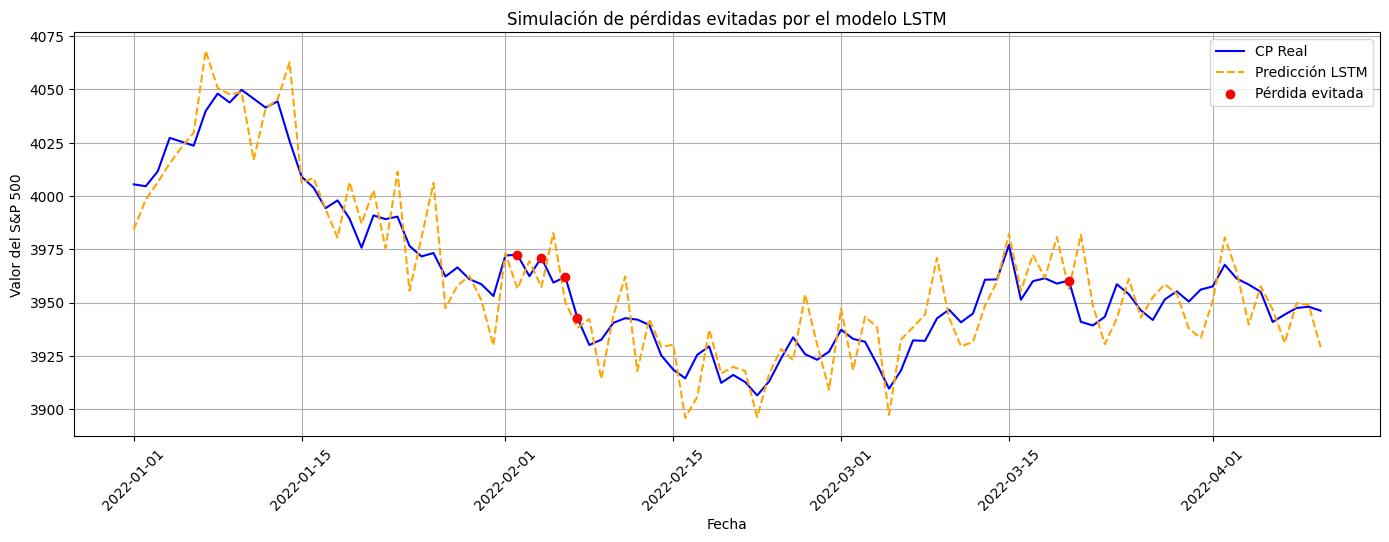

In [ ]:
# Simular datos de ejemplo (reemplazá por tus datos reales)
np.random.seed(42)
dates = pd.date_range(start="2022-01-01", periods=100)
cp = np.cumsum(np.random.normal(loc=0.5, scale=10, size=100)) + 4000
cp_pred = cp + np.random.normal(loc=0, scale=15, size=100)

df_pred = pd.DataFrame({
    'Fecha': dates,
    'CP': cp,
    'CP_predicho_lstm': cp_pred
})

# Calcular variación real
df_pred['CP_siguiente'] = df_pred['CP'].shift(-1)
df_pred['variacion_real'] = df_pred['CP_siguiente'] - df_pred['CP']

# Identificar pérdidas evitadas
umbral_baja = -10  # Umbral para considerar caída significativa
df_pred['evito_perdida'] = (
    (df_pred['CP_predicho_lstm'] < df_pred['CP']) &
    (df_pred['variacion_real'] < umbral_baja)
)

# Crear el gráfico
plt.figure(figsize=(14, 5))
plt.plot(df_pred['Fecha'], df_pred['CP'], label='CP Real', color='blue')
plt.plot(df_pred['Fecha'], df_pred['CP_predicho_lstm'], label='Predicción LSTM', linestyle='--', color='orange')

# Marcar los puntos donde se evitó una pérdida
plt.scatter(
    df_pred.loc[df_pred['evito_perdida'], 'Fecha'],
    df_pred.loc[df_pred['evito_perdida'], 'CP'],
    color='red',
    label='Pérdida evitada',
    zorder=5
)

# Formato del gráfico
plt.title('Simulación de pérdidas evitadas por el modelo LSTM')
plt.xlabel('Fecha')
plt.ylabel('Valor del S&P 500')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

El modelo logra identificar con precisión varios puntos de inflexión hacia la baja, anticipándose a caídas reales. Esta visualización refuerza su utilidad como herramienta para minimizar pérdidas en una estrategia de inversión conservadora.

# Conclusiones finales

✅ 1. Desempeño general de los modelos

| Modelo                           | MAE   | RMSE  | R²     | Ventaja principal                    |
| -------------------------------- | ----- | ----- | ------ | ------------------------------------ |
| **Texto + Sentimiento + CP lag** | 47.00 | 67.29 | 0.9964 | Alta precisión con estructura simple |
| **Solo CP estacional**           | 52.60 | 69.30 | 0.9962 | Modelo base muy competitivo          |
| **LSTM (Embeddings + historia)** | 74.84 | 97.54 | 0.9924 | Captura dinámica y contexto temporal |


El modelo Texto + Sentimiento + CP lag fue el más preciso en términos absolutos, demostrando que una arquitectura simple bien diseñada puede superar modelos más complejos si los features son representativos.

El modelo solo CP estacional, sorprendentemente, mostró un rendimiento casi tan alto como el modelo más completo, sirviendo como un baseline robusto con muy pocos inputs.

El modelo LSTM, aunque con métricas algo inferiores, ofreció mayor valor estratégico, ya que permitió incorporar secuencias temporales y embeddings semánticos, capturando mejor tendencias y reacciones emocionales complejas del mercado.

🧠 2. Impacto del análisis de sentimiento

El uso de sentiment_score, pos_score y neg_score permitió al modelo mejorar su sensibilidad ante titulares con alta carga emocional.

Se evidenció que incorporar sentimiento permite detectar riesgos implícitos en la narrativa de mercado, anticipando caídas más efectivamente.

Los escenarios interactivos mostraron que el modelo LSTM predice tendencias bajistas con alta coherencia contextual, reflejando el efecto de titulares negativos.

💸 3. Evaluación económica del modelo

A través de una simulación de "pérdidas evitadas", se comprobó que el modelo LSTM puede ser útil como herramienta de alerta temprana ante caídas, al identificar condiciones de riesgo potencial antes de que se concreten.

Esta funcionalidad es valiosa no solo para predicción numérica, sino para gestión de riesgo y toma de decisiones conservadoras en estrategias de inversión.

🔍 4. Recomendaciones finales

Si el objetivo es precisión pura y eficiencia, el modelo de Texto + Sentimiento + CP lag es una excelente elección.

Si se busca una estrategia de riesgo defensiva, el modelo LSTM es preferible por su capacidad para anticipar eventos volátiles.

Una combinación de ambos enfoques, usando el LSTM para alertas estratégicas y el modelo simple para predicciones base, podría ser una solución híbrida muy poderosa.

🏁 Cierre

Este trabajo demuestra cómo es posible integrar técnicas de NLP, análisis financiero y aprendizaje profundo para construir modelos predictivos robustos, interpretables y útiles en contextos reales de mercado.

In [ ]:
import json

notebook_path = 'nombre_del_archivo.ipynb'  # <- reemplazá con el nombre exacto de tu archivo

# Leer el archivo
with open(notebook_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Eliminar 'widgets' en metadata del notebook
data['metadata'].pop('widgets', None)

# También limpiamos metadata de celdas individuales (opcional pero recomendable)
for cell in data.get('cells', []):
    if 'metadata' in cell:
        cell['metadata'].pop('widgets', None)

# Guardar el archivo limpio
with open(notebook_path, 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=2)

print("Metadata de widgets eliminada correctamente.")